# Modul 5: GPU Computing Dasar – CUDA
## Langkah 1: Setup dan Verifikasi Lingkungan



In [1]:
import subprocess, os, re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Verifikasi NVCC
r = subprocess.run(['nvcc','--version'], capture_output=True, text=True)
print('=== NVCC Version ==='); print(r.stdout.strip())

# Info GPU
r2 = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print('\n=== GPU Info ==='); print(r2.stdout)

=== NVCC Version ===
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Fri_Jan__6_16:45:21_PST_2023
Cuda compilation tools, release 12.0, V12.0.140
Build cuda_12.0.r12.0/compiler.32267302_0

=== GPU Info ===
Thu Jun 11 21:20:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.110                Driver Version: 581.86         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:01:00.0 Off |        

In [2]:
# Buat direktori kerja
os.makedirs('cuda_files', exist_ok=True)
print('Direktori cuda_files siap.')

# Cek compute capability GPU
r3 = subprocess.run(
    'nvidia-smi --query-gpu=name,compute_cap,memory.total --format=csv,noheader',
    shell=True, capture_output=True, text=True)
print('GPU Details:', r3.stdout.strip())


Direktori cuda_files siap.
GPU Details: NVIDIA GeForce RTX 3050 6GB Laptop GPU, 8.6, 6144 MiB


## Langkah 2: CPU Serial – Baseline

In [1]:
%%writefile cuda_files/vector_add_cpu.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>

void vector_add_cpu(float* A, float* B, float* C, int N) {
    for (int i = 0; i < N; i++) C[i] = A[i] + B[i];
}

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 10000000;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i = 0; i < N; i++) {
        A[i] = (float)rand()/RAND_MAX;
        B[i] = (float)rand()/RAND_MAX;
    }
    auto t0 = std::chrono::high_resolution_clock::now();
    vector_add_cpu(A.data(), B.data(), C.data(), N);
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok = true;
    for (int i=0;i<10;i++) if (fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw = (3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,ms,bw,(int)ok);
    return 0;
}


Overwriting cuda_files/vector_add_cpu.cpp


In [2]:
!g++ -O2 -std=c++11 cuda_files/vector_add_cpu.cpp -o cuda_files/vec_cpu
!./cuda_files/vec_cpu 10000000   # uji dengan 10 juta elemen

N=10000000 TIME_MS=6.0619 BW=19.7957 CORRECT=1


## Langkah 3: CPU dengan OpenMP (Parallel Baseline)

In [3]:
%%writefile cuda_files/vector_add_openmp.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <cmath>
#include <omp.h>

int main(int argc, char* argv[]) {
    int N = (argc>1)?atoi(argv[1]):10000000;
    int T = (argc>2)?atoi(argv[2]):4;
    std::vector<float> A(N), B(N), C(N);
    srand(42);
    for (int i=0;i<N;i++){A[i]=(float)rand()/RAND_MAX;B[i]=(float)rand()/RAND_MAX;}
    omp_set_num_threads(T);
    auto t0 = std::chrono::high_resolution_clock::now();
    #pragma omp parallel for
    for (int i=0;i<N;i++) C[i]=A[i]+B[i];
    auto t1 = std::chrono::high_resolution_clock::now();
    double ms = std::chrono::duration<double,std::milli>(t1-t0).count();
    bool ok=true;
    for(int i=0;i<10;i++) if(fabs(C[i]-(A[i]+B[i]))>1e-6){ok=false;break;}
    float bw=(3.0f*N*sizeof(float))/(ms/1000.0f)/1e9;
    printf("N=%d THREADS=%d TIME_MS=%.4f BW=%.4f CORRECT=%d\n",N,T,ms,bw,(int)ok);
    return 0;
}


Writing cuda_files/vector_add_openmp.cpp


In [4]:
!g++ -O2 -std=c++11 -fopenmp cuda_files/vector_add_openmp.cpp -o cuda_files/vec_omp
!./cuda_files/vec_omp 10000000 4   # 10M elemen, 4 thread


N=10000000 THREADS=4 TIME_MS=6.8390 BW=17.5463 CORRECT=1


## Langkah 4: CUDA Basic – GPU Kernel

In [9]:
%%writefile cuda_files/vector_add_cuda.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>
#include <cstdio>

#define CHECK(call)                                                   \
do {                                                                  \
    cudaError_t e = (call);                                           \
    if (e != cudaSuccess) {                                           \
        fprintf(stderr, "CUDA error %s:%d: %s\n",                     \
                __FILE__, __LINE__, cudaGetErrorString(e));           \
        exit(EXIT_FAILURE);                                           \
    }                                                                 \
} while(0)

__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) {
        C[idx] = A[idx] + B[idx];
    }
}

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc > 2) ? atoi(argv[2]) : 256;

    size_t sz = N * sizeof(float);

    float *h_A = new float[N];
    float *h_B = new float[N];
    float *h_C = new float[N];

    srand(42);

    for (int i = 0; i < N; i++) {
        h_A[i] = (float)rand() / RAND_MAX;
        h_B[i] = (float)rand() / RAND_MAX;
    }

    float *d_A, *d_B, *d_C;

    CHECK(cudaMalloc(&d_A, sz));
    CHECK(cudaMalloc(&d_B, sz));
    CHECK(cudaMalloc(&d_C, sz));

    cudaEvent_t ev0, ev1;

    CHECK(cudaEventCreate(&ev0));
    CHECK(cudaEventCreate(&ev1));

    float t_htod = 0.0f;
    float t_kernel = 0.0f;
    float t_dtoh = 0.0f;

    CHECK(cudaEventRecord(ev0));

    CHECK(cudaMemcpy(d_A, h_A, sz, cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B, h_B, sz, cudaMemcpyHostToDevice));

    CHECK(cudaEventRecord(ev1));
    CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod, ev0, ev1));

    int blocks = (N + TPB - 1) / TPB;

    CHECK(cudaEventRecord(ev0));

    vec_add<<<blocks, TPB>>>(d_A, d_B, d_C, N);

    CHECK(cudaGetLastError());

    CHECK(cudaEventRecord(ev1));
    CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel, ev0, ev1));

    CHECK(cudaEventRecord(ev0));

    CHECK(cudaMemcpy(h_C, d_C, sz, cudaMemcpyDeviceToHost));

    CHECK(cudaEventRecord(ev1));
    CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh, ev0, ev1));

    float total = t_htod + t_kernel + t_dtoh;

    bool ok = true;

    for (int i = 0; i < 10; i++) {
        if (fabs(h_C[i] - (h_A[i] + h_B[i])) > 1e-6) {
            ok = false;
            break;
        }
    }

    printf(
        "N=%d TPB=%d BLOCKS=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
        N, TPB, blocks, t_htod, t_kernel, t_dtoh, total, (int)ok
    );

    delete[] h_A;
    delete[] h_B;
    delete[] h_C;

    CHECK(cudaFree(d_A));
    CHECK(cudaFree(d_B));
    CHECK(cudaFree(d_C));

    CHECK(cudaEventDestroy(ev0));
    CHECK(cudaEventDestroy(ev1));

    return 0;
}

Overwriting cuda_files/vector_add_cuda.cu


In [10]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_cuda.cu -o cuda_files/vec_cuda
!./cuda_files/vec_cuda 10000000 256   # 10M elemen, 256 thread per block


N=10000000 TPB=256 BLOCKS=39063 HTOD=11.1799 KERNEL=4.7177 DTOH=23.4934 TOTAL=39.3910 CORRECT=1


## Langkah 5: CUDA Pinned Memory – Transfer Lebih Cepat

In [13]:
%%writefile cuda_files/vector_add_pinned.cu
#include <iostream>
#include <cuda_runtime.h>
#include <cstdlib>
#include <cmath>
#include <cstdio>

#define CHECK(call)                                                   \
do {                                                                  \
    cudaError_t e = (call);                                           \
    if (e != cudaSuccess) {                                           \
        fprintf(stderr, "CUDA error %s:%d: %s\n",                     \
                __FILE__, __LINE__, cudaGetErrorString(e));           \
        exit(EXIT_FAILURE);                                           \
    }                                                                 \
} while(0)

__global__ void vec_add(float* A, float* B, float* C, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) {
        C[idx] = A[idx] + B[idx];
    }
}

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 10000000;
    int TPB = (argc > 2) ? atoi(argv[2]) : 256;

    size_t sz = N * sizeof(float);

    float *h_A, *h_B, *h_C;

    CHECK(cudaHostAlloc(&h_A, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_B, sz, cudaHostAllocDefault));
    CHECK(cudaHostAlloc(&h_C, sz, cudaHostAllocDefault));

    srand(42);

    for (int i = 0; i < N; i++) {
        h_A[i] = (float)rand() / RAND_MAX;
        h_B[i] = (float)rand() / RAND_MAX;
    }

    float *d_A, *d_B, *d_C;

    CHECK(cudaMalloc(&d_A, sz));
    CHECK(cudaMalloc(&d_B, sz));
    CHECK(cudaMalloc(&d_C, sz));

    cudaEvent_t ev0, ev1;

    CHECK(cudaEventCreate(&ev0));
    CHECK(cudaEventCreate(&ev1));

    float t_htod = 0.0f;
    float t_kernel = 0.0f;
    float t_dtoh = 0.0f;

    CHECK(cudaEventRecord(ev0));

    CHECK(cudaMemcpy(d_A, h_A, sz, cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B, h_B, sz, cudaMemcpyHostToDevice));

    CHECK(cudaEventRecord(ev1));
    CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_htod, ev0, ev1));

    int blocks = (N + TPB - 1) / TPB;

    CHECK(cudaEventRecord(ev0));

    vec_add<<<blocks, TPB>>>(d_A, d_B, d_C, N);

    CHECK(cudaGetLastError());

    CHECK(cudaEventRecord(ev1));
    CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_kernel, ev0, ev1));

    CHECK(cudaEventRecord(ev0));

    CHECK(cudaMemcpy(h_C, d_C, sz, cudaMemcpyDeviceToHost));

    CHECK(cudaEventRecord(ev1));
    CHECK(cudaEventSynchronize(ev1));
    CHECK(cudaEventElapsedTime(&t_dtoh, ev0, ev1));

    float total = t_htod + t_kernel + t_dtoh;

    bool ok = true;

    for (int i = 0; i < 10; i++) {
        if (fabs(h_C[i] - (h_A[i] + h_B[i])) > 1e-6) {
            ok = false;
            break;
        }
    }

    printf(
        "N=%d TPB=%d BLOCKS=%d HTOD=%.4f KERNEL=%.4f DTOH=%.4f TOTAL=%.4f CORRECT=%d\n",
        N,
        TPB,
        blocks,
        t_htod,
        t_kernel,
        t_dtoh,
        total,
        (int)ok
    );

    CHECK(cudaFreeHost(h_A));
    CHECK(cudaFreeHost(h_B));
    CHECK(cudaFreeHost(h_C));

    CHECK(cudaFree(d_A));
    CHECK(cudaFree(d_B));
    CHECK(cudaFree(d_C));

    CHECK(cudaEventDestroy(ev0));
    CHECK(cudaEventDestroy(ev1));

    return 0;
}

Overwriting cuda_files/vector_add_pinned.cu


In [14]:
!nvcc -O2 -std=c++11 cuda_files/vector_add_pinned.cu -o cuda_files/vec_pinned
!./cuda_files/vec_pinned 10000000 256


N=10000000 TPB=256 BLOCKS=39063 HTOD=6.4100 KERNEL=2.2014 DTOH=3.1966 TOTAL=11.8081 CORRECT=1


## Langkah 6: Eksperimen Otomatis – Variasi Ukuran Data

In [17]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def parse_cpu(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

def parse_cuda(out):
    d={}
    for tok in out.split():
        if '=' in tok: k,v=tok.split('='); d[k]=v
    return d

sizes = [1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
results = []

for N in sizes:
    row = {'N': N}
    # CPU Serial
    r = subprocess.run(f'./cuda_files/vec_cpu {N}',   shell=True,capture_output=True,text=True)
    d = parse_cpu(r.stdout); row['cpu_ms']  = float(d.get('TIME_MS',0))
    # OpenMP (4 thread)
    r = subprocess.run(f'./cuda_files/vec_omp {N} 4', shell=True,capture_output=True,text=True)
    d = parse_cpu(r.stdout); row['omp_ms']  = float(d.get('TIME_MS',0))
    # CUDA Basic
    r = subprocess.run(f'./cuda_files/vec_cuda {N} 256',shell=True,capture_output=True,text=True)
    d = parse_cuda(r.stdout)
    row['cuda_htod']   = float(d.get('HTOD',0))
    row['cuda_kernel'] = float(d.get('KERNEL',0))
    row['cuda_dtoh']   = float(d.get('DTOH',0))
    row['cuda_total']  = float(d.get('TOTAL',0))
    # CUDA Pinned
    r = subprocess.run(f'./cuda_files/vec_pinned {N} 256',shell=True,capture_output=True,text=True)
    d = parse_cuda(r.stdout); row['pinned_total'] = float(d.get('TOTAL',0))
    results.append(row)
    print(f'N={N:>12,}: cpu={row["cpu_ms"]:8.2f}ms  omp={row["omp_ms"]:7.2f}ms  cuda={row["cuda_total"]:7.2f}ms  pinned={row["pinned_total"]:7.2f}ms')

df = pd.DataFrame(results)
print('\n=== Eksperimen selesai ===')


N=       1,000: cpu=    0.00ms  omp=   0.21ms  cuda=   1.34ms  pinned=   1.17ms
N=      10,000: cpu=    0.00ms  omp=  11.37ms  cuda=   1.31ms  pinned=   1.06ms
N=     100,000: cpu=    0.03ms  omp=   6.61ms  cuda=   1.32ms  pinned=   1.72ms
N=   1,000,000: cpu=    0.61ms  omp=   8.44ms  cuda=   3.91ms  pinned=   2.23ms
N=  10,000,000: cpu=    6.90ms  omp=   3.89ms  cuda=  33.56ms  pinned=  11.82ms
N= 100,000,000: cpu=   60.35ms  omp=  47.14ms  cuda= 346.62ms  pinned= 110.21ms

=== Eksperimen selesai ===


In [18]:
# Hitung Speedup dan Bandwidth
df['speedup_omp']    = df['cpu_ms'] / df['omp_ms']
df['speedup_cuda']   = df['cpu_ms'] / df['cuda_total']
df['speedup_pinned'] = df['cpu_ms'] / df['pinned_total']
df['pcie_bw_cuda']   = (2*df['N']*4/1e9) / (df['cuda_htod']+df['cuda_dtoh'])*1000  # GB/s
df['pcie_bw_pinned'] = (2*df['N']*4/1e9) / df['pinned_total']*1000

# Cetak tabel ringkasan
print('=== Tabel Waktu Eksekusi (ms) ===')
print(df[['N','cpu_ms','omp_ms','cuda_total','pinned_total']].to_string(index=False))
print('\n=== Tabel Speedup ===')
print(df[['N','speedup_omp','speedup_cuda','speedup_pinned']].to_string(index=False))


=== Tabel Waktu Eksekusi (ms) ===
        N  cpu_ms  omp_ms  cuda_total  pinned_total
     1000  0.0004  0.2065      1.3382        1.1652
    10000  0.0026 11.3680      1.3115        1.0641
   100000  0.0311  6.6054      1.3229        1.7177
  1000000  0.6136  8.4408      3.9082        2.2329
 10000000  6.9046  3.8862     33.5593       11.8190
100000000 60.3517 47.1421    346.6190      110.2113

=== Tabel Speedup ===
        N  speedup_omp  speedup_cuda  speedup_pinned
     1000     0.001937      0.000299        0.000343
    10000     0.000229      0.001982        0.002443
   100000     0.004708      0.023509        0.018106
  1000000     0.072695      0.157003        0.274800
 10000000     1.776697      0.205743        0.584195
100000000     1.280208      0.174115        0.547600


## Langkah 7: Visualisasi Hasil

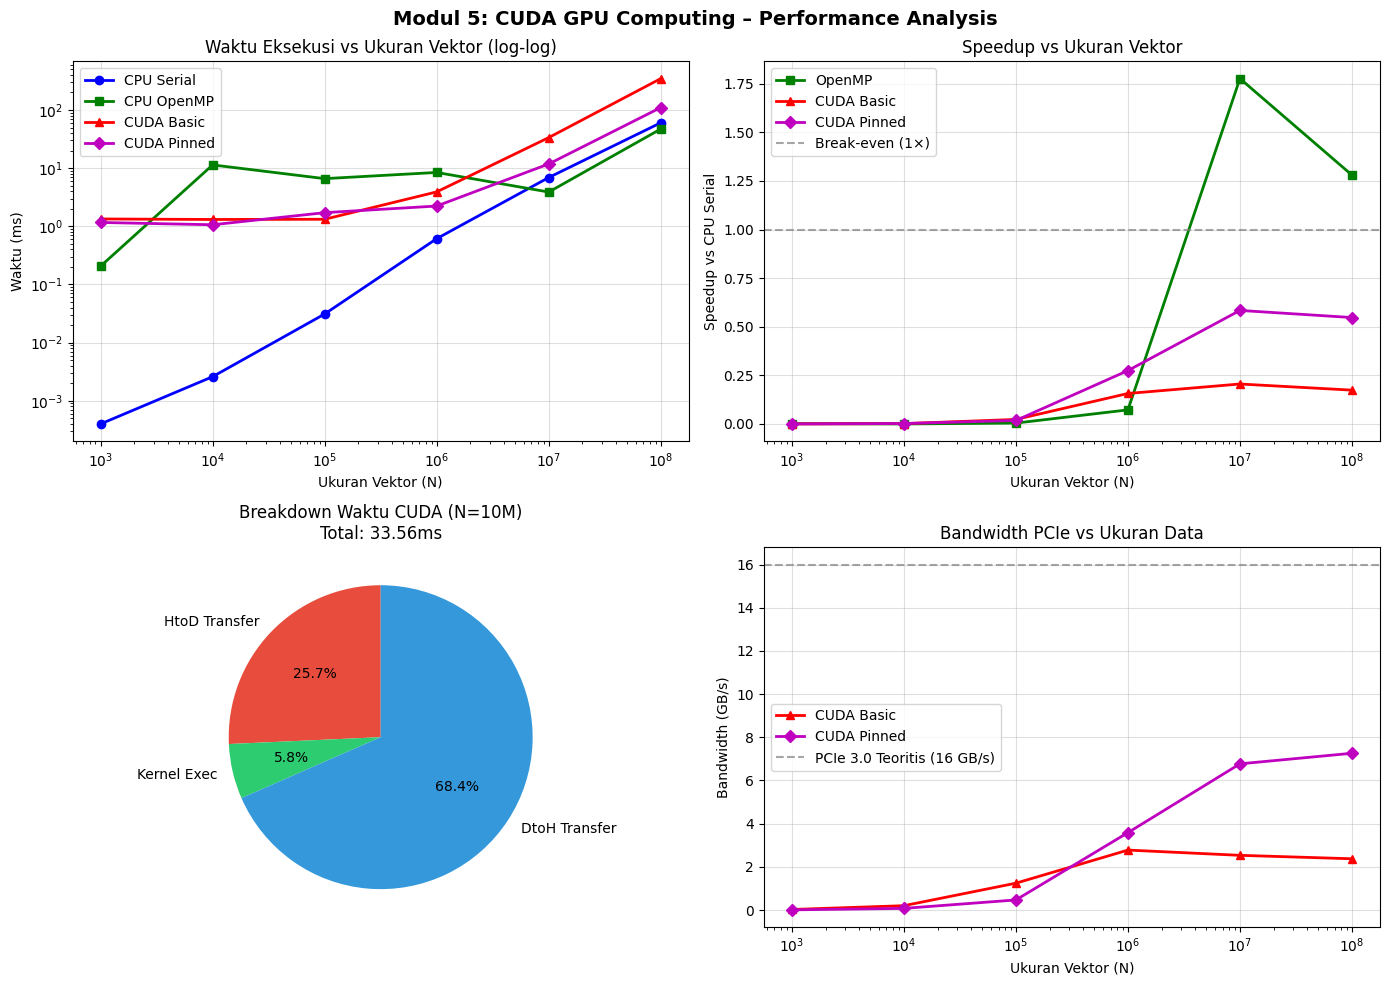

Grafik disimpan ke cuda_files/performance_analysis.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sizes_k = [f'{n//1000}K' if n<1e6 else f'{n//1000000}M' for n in df['N']]

# Grafik 1: Waktu Eksekusi (log scale)
ax = axes[0,0]
ax.loglog(df['N'], df['cpu_ms'],    'b-o', label='CPU Serial',  linewidth=2)
ax.loglog(df['N'], df['omp_ms'],    'g-s', label='CPU OpenMP',  linewidth=2)
ax.loglog(df['N'], df['cuda_total'],'r-^', label='CUDA Basic',  linewidth=2)
ax.loglog(df['N'], df['pinned_total'],'m-D',label='CUDA Pinned',linewidth=2)
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Waktu (ms)')
ax.set_title('Waktu Eksekusi vs Ukuran Vektor (log-log)'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 2: Speedup vs CPU Serial
ax = axes[0,1]
ax.semilogx(df['N'], df['speedup_omp'],   'g-s', label='OpenMP',      linewidth=2)
ax.semilogx(df['N'], df['speedup_cuda'],  'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['speedup_pinned'],'m-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Break-even (1×)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Speedup vs CPU Serial')
ax.set_title('Speedup vs Ukuran Vektor'); ax.legend(); ax.grid(True,alpha=0.4)

# Grafik 3: CUDA Breakdown (10M elemen)
ax = axes[1,0]
row10m = df[df['N']==10_000_000].iloc[0]
labels_b = ['HtoD Transfer','Kernel Exec','DtoH Transfer']
vals_b = [row10m['cuda_htod'], row10m['cuda_kernel'], row10m['cuda_dtoh']]
colors_b = ['#E74C3C','#2ECC71','#3498DB']
wedges,texts,autotexts = ax.pie(vals_b, labels=labels_b, colors=colors_b,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize':10})
ax.set_title(f'Breakdown Waktu CUDA (N=10M)\nTotal: {row10m["cuda_total"]:.2f}ms')

# Grafik 4: Bandwidth PCIe
ax = axes[1,1]
ax.semilogx(df['N'], df['pcie_bw_cuda'],   'r-^', label='CUDA Basic',  linewidth=2)
ax.semilogx(df['N'], df['pcie_bw_pinned'], 'm-D', label='CUDA Pinned', linewidth=2)
ax.axhline(y=16, color='gray', linestyle='--', alpha=0.7, label='PCIe 3.0 Teoritis (16 GB/s)')
ax.set_xlabel('Ukuran Vektor (N)'); ax.set_ylabel('Bandwidth (GB/s)')
ax.set_title('Bandwidth PCIe vs Ukuran Data'); ax.legend(); ax.grid(True,alpha=0.4)

plt.suptitle('Modul 5: CUDA GPU Computing – Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cuda_files/performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke cuda_files/performance_analysis.png')


## Langkah 8: Eksperimen Konfigurasi Thread per Block

TPB=   32: kernel=2.3395ms  total=32.8471ms
TPB=   64: kernel=1.7086ms  total=25.7665ms
TPB=  128: kernel=2.4647ms  total=42.4933ms
TPB=  256: kernel=1.6013ms  total=28.8850ms
TPB=  512: kernel=1.6481ms  total=31.1145ms
TPB= 1024: kernel=1.7038ms  total=33.2506ms

=== Tabel Thread per Block ===
 ThreadsPerBlock  Blocks  Kernel_ms  Total_ms
              32  312500     2.3395   32.8471
              64  156250     1.7086   25.7665
             128   78125     2.4647   42.4933
             256   39063     1.6013   28.8850
             512   19532     1.6481   31.1145
            1024    9766     1.7038   33.2506


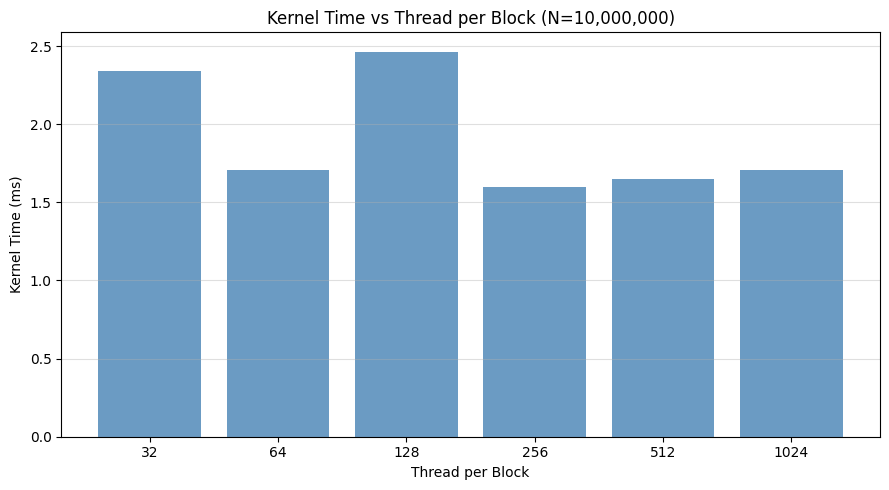

In [20]:
tpb_configs = [32, 64, 128, 256, 512, 1024]
N_test = 10_000_000
tpb_results = []

for tpb in tpb_configs:
    r = subprocess.run(f'./cuda_files/vec_cuda {N_test} {tpb}',
                       shell=True, capture_output=True, text=True)
    d = parse_cuda(r.stdout)
    tpb_results.append({
        'ThreadsPerBlock': tpb,
        'Blocks'         : int(d.get('BLOCKS', 0)),
        'Kernel_ms'      : float(d.get('KERNEL',0)),
        'Total_ms'       : float(d.get('TOTAL',0))
    })
    print(f'TPB={tpb:5d}: kernel={float(d.get("KERNEL",0)):.4f}ms  total={float(d.get("TOTAL",0)):.4f}ms')

df_tpb = pd.DataFrame(tpb_results)
print('\n=== Tabel Thread per Block ===')
print(df_tpb.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(range(len(tpb_configs)), df_tpb['Kernel_ms'], color='steelblue', alpha=0.8)
ax.set_xticks(range(len(tpb_configs)))
ax.set_xticklabels([str(t) for t in tpb_configs])
ax.set_xlabel('Thread per Block'); ax.set_ylabel('Kernel Time (ms)')
ax.set_title(f'Kernel Time vs Thread per Block (N={N_test:,})')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.savefig('cuda_files/tpb_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
